Firstly, we import the libraries needed for the analysis.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

Now we are going to download all the stock info for the selected companies, using yfinance. This library works as an API which extracts all the data from Yahoo! Finance.

In [58]:
# These are the companies' tickers in their stock market. We have to consider that Alphabet(Google), 
# has two separate tickers: GOOG lacks voting rights and GOOGL does not. 

tickers = ['AAPL', 
           'MSFT',
           'GOOG',
           'NVDA',
           'AMZN',
           'META',
           'TSLA',
           'GOOGL']

# We download all the data since 2020 until this day.

data = yf.download(tickers,
            start='2020-01-01',
            end='2026-06-14',
            auto_adjust=True)

[*********************100%***********************]  8 of 8 completed


We filter to get the closing price of the stock

In [59]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,AMZN,GOOG,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2020-01-02,72.333878,94.900497,67.770981,67.832512,207.953857,151.829575,5.963803,28.684000
2020-01-03,71.630638,93.748497,67.438423,67.477669,206.853516,149.939026,5.868347,29.534000
2020-01-06,72.201416,95.143997,69.101257,69.276199,210.749298,150.326553,5.892956,30.102667
2020-01-07,71.861824,95.343002,69.058121,69.142403,211.205276,148.955902,5.964302,31.270666
2020-01-08,73.017845,94.598503,69.602333,69.634529,213.346497,151.328568,5.975488,32.809334


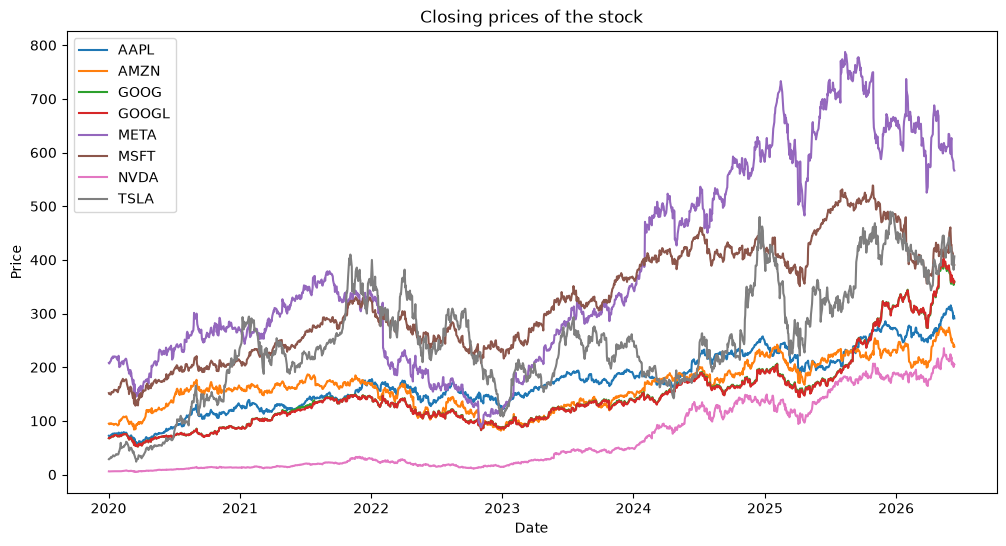

In [60]:
plt.figure(figsize=(12,6))

for stock in close_prices.columns:
    plt.plot(close_prices.index,
             close_prices[stock],
             label=stock)
    
plt.title("Closing prices of the stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()


Nonetheless, we have to consider that their initial share prices differ significantly. As a result, we are going to normalize its prices so we can see their real growth, comparing their prices with the inital one.

### Price Normalization

Since the stocks have very different starting prices, direct comparisons can be misleading.

To compare their relative performance, prices are normalized using:

$$
P_{normalized}
=
\frac{P_t}
{P_0}
$$

Where:

- $P_t$ is the stock price at time $t$.
- $P_0$ is the initial stock price.

After normalization, all stocks start at 1, allowing us to compare their relative growth over time.

In [61]:
normalised_closing_prices = close_prices / close_prices.iloc[0]

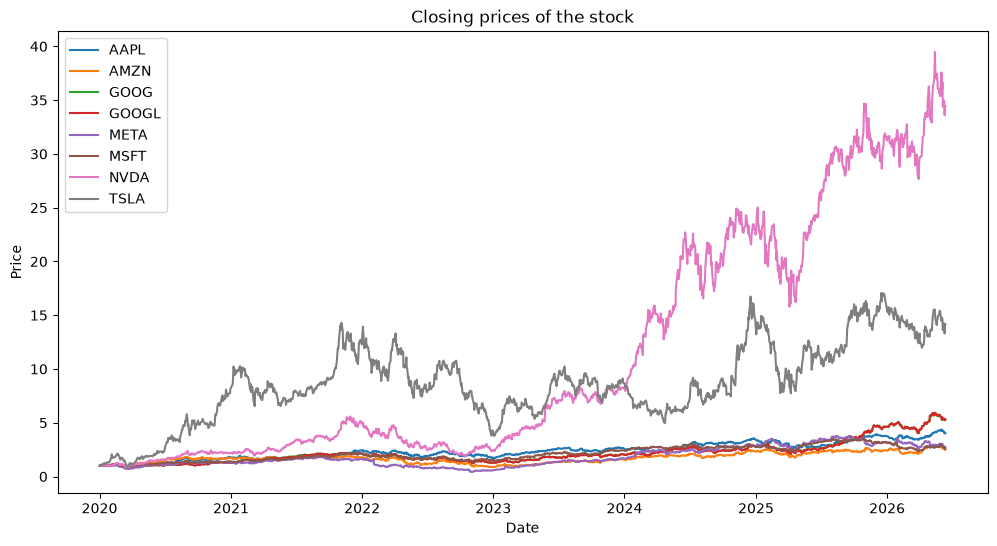

In [62]:
plt.figure(figsize=(12,6))

for stock in normalised_closing_prices.columns:
    plt.plot(normalised_closing_prices.index,
             normalised_closing_prices[stock],
             label=stock)
    
plt.title("Closing prices of the stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()


As seen in the plot, Tesla and, especially, Nvidia experienced significant growth during the last 6 years. At the same time, it is visible that they also happen to be the most volatile among the analysed companies. Meanwhile, the rest show much more modest growth, while remaining more stable and conservative. Over the last 6 years, Amazon appears to have had minor growth compared to the rest.

In regard to Nvidia, it clearly shows a massive growth in 2024 and 2025. A possibility could be that thanks to the rise of the AI industry, resulted in the increase in demand for GPUs used mainly for LLMs, data processing from data centers, AI model training... 

## Total Rentability

Next, we'll proceed to calculate the total return of said companies based on the variation of their closing prices. This consists in the percentage of change between the inital and final share price, over the course of this period. 

### Total Return Formula

The total return is calculated as the percentage change between the initial and final stock prices.

$$
\text{Total Return (\%)} =
\frac{P_{final}-P_{initial}}
{P_{initial}}
\times 100
$$

Where:

- $P_{initial}$ is the initial stock price.
- $P_{final}$ is the final stock price.

In [63]:
total_returns = (
    (normalised_closing_prices.iloc[-1] - 1) * 100
)

total_returns.sort_values(ascending=False)

Ticker
NVDA     3340.589986
TSLA     1316.922300
GOOGL     430.247197
GOOG      428.485790
AAPL      302.480849
META      172.394541
MSFT      157.354334
AMZN      151.368549
Name: 2026-06-12 00:00:00, dtype: float64

Text(0, 0.5, 'Company')

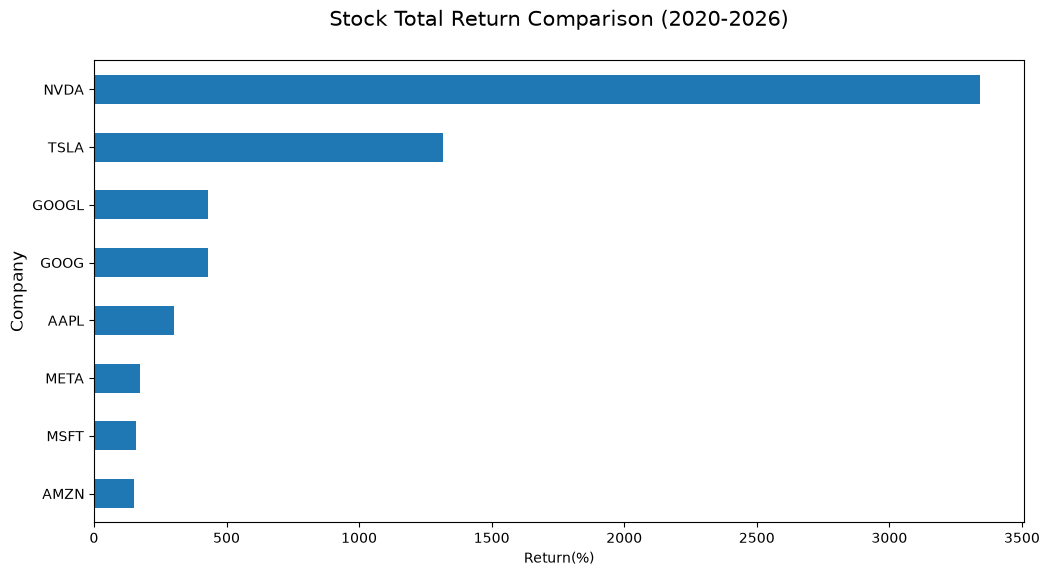

In [72]:
total_returns.sort_values().plot.barh(figsize=(12,6))

plt.title("Stock Total Return Comparison (2020-2026)", fontsize=15, pad=25)
plt.xlabel("Return(%)")
plt.ylabel("Company", fontsize=12)



As previously said, Nvidia stands out with the most astonishing growth among the companies in this matter, with an overall increase of 3340% of its stock prices since 2020, followed by Tesla with an increase of 1316%. The remaining companies had a more moderate growth, but still pretty considerable, being Amazon the one to achieve the slowest growth.

It's really interesting to remark that Nvidia's performance was exceptional, contrasting with the others, since its return is twice the return of Tesla and 11 times the return of Apple.

## Daily Performance

We are going to measure the daily variations in price, so we can later calculate the volatility of these companies.

### Daily Return Formula

Daily returns measure the percentage change in stock price from one trading day to the next.

$$
R_t =
\frac{P_t-P_{t-1}}
{P_{t-1}}
$$

Where:

- $P_t$ is today's closing price.
- $P_{t-1}$ is the previous day's closing price.

In [65]:
daily_changes=close_prices.pct_change().dropna()

daily_changes.head()

Ticker,AAPL,AMZN,GOOG,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.004907,-0.005231,-0.005291,-0.012452,-0.016006,0.029633
2020-01-06,0.007968,0.014886,0.024657,0.026654,0.018834,0.002585,0.004194,0.019255
2020-01-07,-0.004703,0.002092,-0.000624,-0.001931,0.002164,-0.009118,0.012107,0.038801
2020-01-08,0.016087,-0.007809,0.007880,0.007118,0.010138,0.015929,0.001876,0.049205
2020-01-09,0.021241,0.004799,0.011045,0.010498,0.014311,0.012493,0.010983,-0.021945


## Volatility



### Volatility Formula

Volatility is measured as the standard deviation of daily returns.

$$
\sigma =
\sqrt{
\frac{
\sum_{i=1}^{n}
(R_i-\bar{R})^2
}
{n-1}
}
$$

Where:

- $R_i$ represents each daily return.
- $\bar{R}$ is the average daily return.
- $n$ is the number of observations.

In [66]:
volatility = daily_changes.std()

volatility.sort_values(ascending=False)

Ticker
TSLA     0.041023
NVDA     0.032938
META     0.027444
AMZN     0.022275
GOOGL    0.020371
GOOG     0.020252
AAPL     0.019751
MSFT     0.018770
dtype: float64

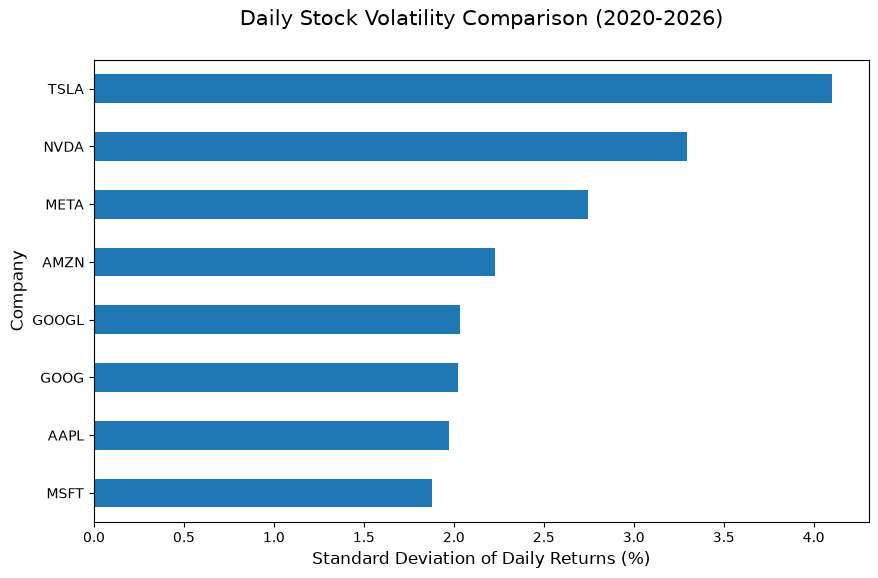

In [67]:
(volatility*100).sort_values().plot.barh(figsize=(10,6))

plt.title("Daily Stock Volatility Comparison (2020-2026)", fontsize=15, pad=25)
plt.xlabel("Standard Deviation of Daily Returns (%)", fontsize=12)
plt.ylabel("Company", fontsize=12)
plt.show()

This graph in particular shows something significantly intriguing regarding Nvidia. Nvidia not only achieves the highest total return by a considerable margin, but also exhibits a volatility inferior to Tesla. 

As for Microsoft, the results are consistent with the observations made from the normalized price chart. While its overall growth was more moderate, it also displayed one of the lowest volatility levels among the companies analyzed. This behavior reflects a more stable and conservative business profile, similar to that of Apple.

## Correlations between the analysed companies.

### Correlation Formula

Correlation measures the degree to which two stocks move together.

$$
\rho_{X,Y}
=
\frac{
\text{Cov}(X,Y)
}
{
\sigma_X \sigma_Y
}
$$

Where:

- $\text{Cov}(X,Y)$ is the covariance between the two stocks.
- $\sigma_X$ and $\sigma_Y$ are the standard deviations of each stock's returns.

Correlation values range from:

$$
-1 \leq \rho \leq 1
$$

- $1$: perfect positive correlation.
- $0$: no correlation.
- $-1$: perfect negative correlation.

In [68]:
correlation = daily_changes.corr()

correlation

Ticker,AAPL,AMZN,GOOG,GOOGL,META,MSFT,NVDA,TSLA
Ticker,,,,,,,,
AAPL,1.000000,0.573536,0.603521,0.603154,0.534970,0.670150,0.564190,0.483604
AMZN,0.573536,1.000000,0.626727,0.623683,0.610407,0.640011,0.564723,0.443802
GOOG,0.603521,0.626727,1.000000,0.995838,0.592177,0.653351,0.558670,0.416797
GOOGL,0.603154,0.623683,0.995838,1.000000,0.591005,0.654815,0.559728,0.415263
META,0.534970,0.610407,0.592177,0.591005,1.000000,0.590467,0.529818,0.354699
MSFT,0.670150,0.640011,0.653351,0.654815,0.590467,1.000000,0.653389,0.435811
NVDA,0.564190,0.564723,0.558670,0.559728,0.529818,0.653389,1.000000,0.475345
TSLA,0.483604,0.443802,0.416797,0.415263,0.354699,0.435811,0.475345,1.000000


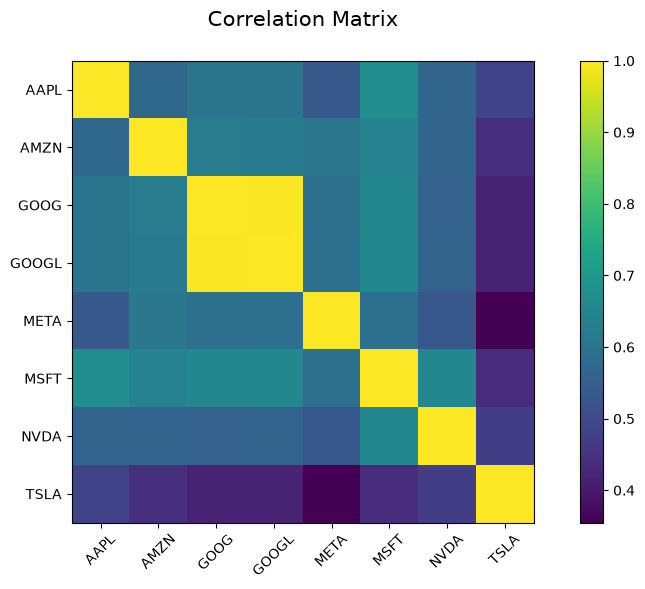

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix", fontsize=15, pad=25)

plt.show()

As shown in the results, the analysed companies from the sector show a moderate correlation between them. There's an obvious strong correlation between Goog and Googl because they both belong to Alphabet and only differ in that Googl grants voting rights to the shareholders.

Microsoft and Apple do show the strongest correlation among them, which means that their stock prices usually tend to move in a similar manner. On the other hand, Tesla is shown to be the least aligned with the rest of the companies from the sector, presenting the weakest correlations in the graph.

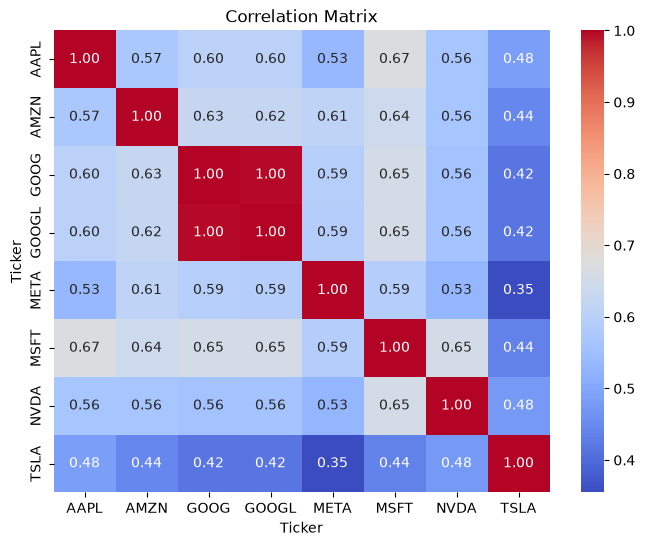

In [83]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Total Return vs Volatility

### Risk vs Return Analysis

A common approach in finance is to compare the return generated by an asset against the risk taken to achieve it.

In this analysis:

- Return is measured using the Total Return (%).
- Risk is approximated using the Volatility (standard deviation of daily returns).

This comparison helps identify companies that delivered higher returns without requiring proportionally higher levels of risk.

In [78]:
risk_return = pd.DataFrame({
    "Return" : total_returns,
    "Volatility" : volatility*100
})

risk_return.sort_values(by="Return", ascending=False)

,Return,Volatility
Ticker,,
NVDA,3340.589986,3.293798
TSLA,1316.922300,4.102341
GOOGL,430.247197,2.037058
GOOG,428.485790,2.025167
AAPL,302.480849,1.975103
META,172.394541,2.744433
MSFT,157.354334,1.876997
AMZN,151.368549,2.227473


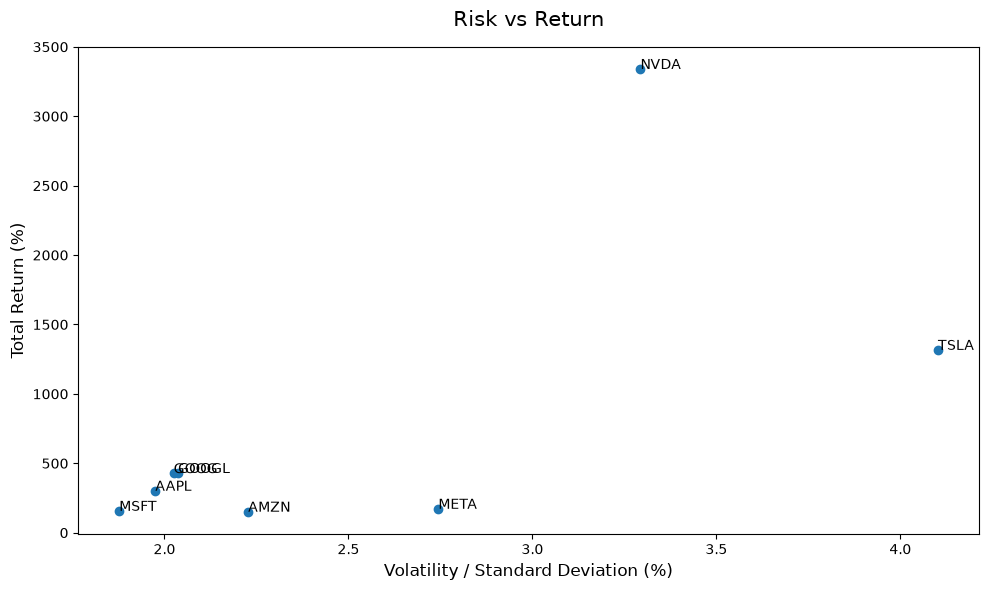

In [82]:
plt.figure(figsize=(10,6))

plt.scatter(
    risk_return["Volatility"],
    risk_return["Return"]
)

for ticker in risk_return.index:
    plt.annotate(
        ticker,
        (
            risk_return.loc[ticker, "Volatility"],
            risk_return.loc[ticker, "Return"]
        )
    )

plt.xlabel("Volatility / Standard Deviation (%)", fontsize=12)
plt.ylabel("Total Return (%)", fontsize=12)
plt.title("Risk vs Return", fontsize=15, pad=15)

plt.tight_layout()

plt.show()

## Final Conclusions & Stock Insights

In terms of total return, Nvidia achieved the highest performance with a substantial return of 3340 % of its initial share price, followed by Tesla with a final return of 1316 %. As previously stated, the rest showed more moderate growth. Amazon experienced the slowest overall growth over the course of this period (2020-2026).

When it comes to volatility, Nvidia surprisingly does not present the most volatile behaviour, being the second right behind Tesla. This suggests that Nvidia delivered an attractive risk-return profile during the analyzed period. On the other hand, Microsoft and Apple while not showing a rapid growth, they do stand out because of their low volatility.

At last, these companies which belong to the technological sector exhibited a moderate correlation in their stock price movements, with the sole exception of Tesla, differing from the rest of the companies in that Tesla is the least aligned based on its stock behaviour.